In [1]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_tickets_200k.csv to customer_support_tickets_200k.csv


In [2]:
import pandas as pd

df = pd.read_csv('customer_support_tickets_200k.csv')

df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [3]:
print(df.columns)

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')


In [4]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  object 
 2   customer_email               200000 non-null  object 
 3   product                      200000 non-null  object 
 4   category                     200000 non-null  object 
 5   issue_description            200000 non-null  object 
 6   resolution_notes             200000 non-null  object 
 7   priority                     200000 non-null  object 
 8   status                       200000 non-null  object 
 9   channel                      200000 non-null  object 
 10  region                       200000 non-null  object 
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  object 
 13 

In [5]:
# Estadísticas básicas
df.describe()

,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,46.469040,30.377675,9.992115,3.001065,36.309180,120.539718,5.501365
std,57735.171256,16.754304,17.326224,6.053142,1.412273,20.654575,68.969143,2.875587
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.500000,1.000000,1.000000
25%,50000.750000,32.000000,15.000000,5.000000,2.000000,18.460000,60.810000,3.000000
50%,100000.500000,46.000000,30.000000,10.000000,3.000000,36.310000,120.450000,6.000000
75%,150000.250000,61.000000,45.000000,15.000000,4.000000,54.220000,180.260000,8.000000
max,200000.000000,75.000000,60.000000,20.000000,5.000000,72.000000,240.000000,10.000000


In [6]:
# Valores nulos
df.isnull().sum()

,0
ticket_id,0
customer_name,0
customer_email,0
product,0
category,0
issue_description,0
resolution_notes,0
priority,0
status,0
channel,0


In [7]:
# Convertir columnas de fecha
df['ticket_created_date'] = pd.to_datetime(df['ticket_created_date'])
df['ticket_resolved_date'] = pd.to_datetime(df['ticket_resolved_date'])

In [8]:
avg_csat = df['customer_satisfaction_score'].mean()

print("Average Customer Satisfaction:", avg_csat)

Average Customer Satisfaction: 3.001065


In [9]:
avg_resolution = df['resolution_time_hours'].mean()

print("Average Resolution Time:", avg_resolution)

Average Resolution Time: 120.53971774999998


In [10]:
escalated_tickets = df['escalated'].value_counts()

print(escalated_tickets)

escalated
Yes    100421
No      99579
Name: count, dtype: int64


In [11]:
sla_breach = df['sla_breached'].value_counts()

print(sla_breach)

sla_breached
Yes    100043
No      99957
Name: count, dtype: int64


In [12]:
priority_count = df['priority'].value_counts()

print(priority_count)

priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64


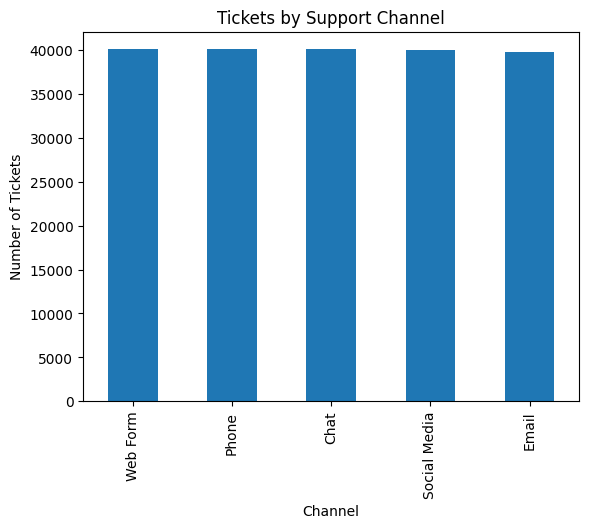

In [13]:
import matplotlib.pyplot as plt

channel_counts = df['channel'].value_counts()

channel_counts.plot(kind='bar')

plt.title('Tickets by Support Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Tickets')

plt.show()

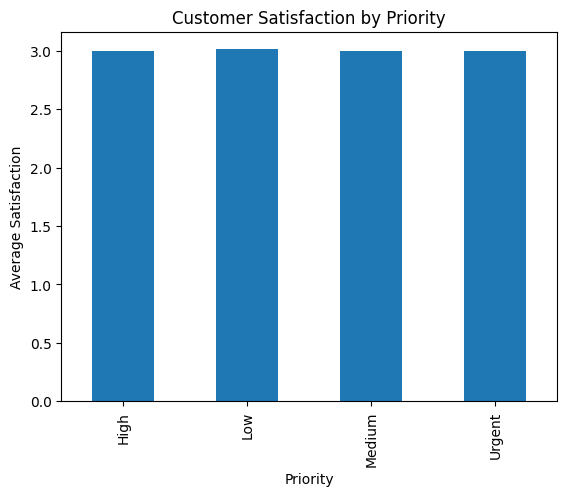

In [14]:
satisfaction_priority = df.groupby('priority')['customer_satisfaction_score'].mean()

satisfaction_priority.plot(kind='bar')

plt.title('Customer Satisfaction by Priority')
plt.xlabel('Priority')
plt.ylabel('Average Satisfaction')

plt.show()

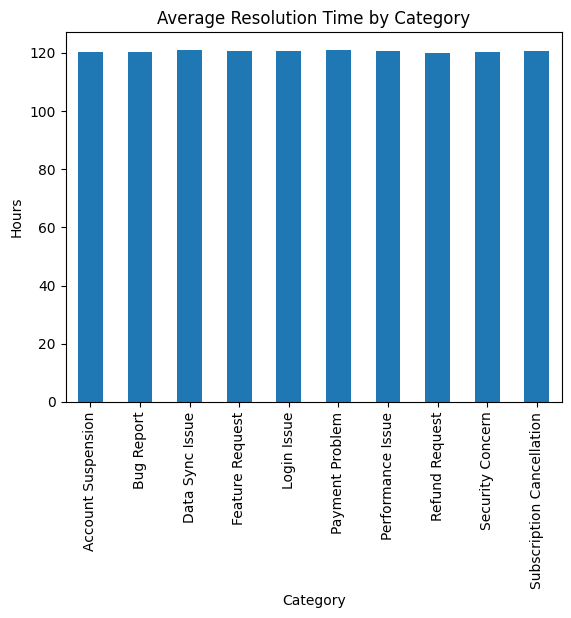

In [15]:
resolution_category = df.groupby('category')['resolution_time_hours'].mean()

resolution_category.plot(kind='bar')

plt.title('Average Resolution Time by Category')
plt.xlabel('Category')
plt.ylabel('Hours')

plt.show()